# DAQ into pandas

A run into a DataFrame, scaled by the board's record.

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated_device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


In [3]:
daq = device.daq
daq.open()
daq.enable()
device.set_time_from_pc(reference='pc')
daq.configure('phaseU', 'phaseV', 'phaseW', 'DC bus', 'NTC', sample_rate=100)
daq.start()
records = daq.read(300)
daq.stop()
print(len(records), 'records;', daq.channel_names(records[0]))

300 records; ['Phase U', 'Phase V', 'Phase W', 'NTC', 'DC bus']


`scaled=True` adds one column per channel in real units beside the codes, through the board's own converters and the channel trims in its calibration record (invariant 7). `stored` says whether that record was ever written or is the schematic's arithmetic; an uncalibrated board answers an empty record and every converter falls back to the compiled-in constant, which is what `name` says.

In [4]:
cal = device.calibration.read()
print('record stored:', cal['stored'], ' version:', cal['version'],
      ' params held:', len(cal['params']))
for name, params in sorted(device.analog.scaling().items()):
    print('%-8s %s' % (name, params.name))
print('channel trims:', [(c['index'], c['offset_raw'], c['gain_ppm'])
                         for c in cal['channels'][:3]])

record stored: False  version: 0  params held: 0
dcbus    compiled-in fallback, the board sent no record
ntc      compiled-in fallback, the board sent no record
phase    compiled-in fallback, the board sent no record
rail5    compiled-in fallback, the board sent no record
vgate    compiled-in fallback, the board sent no record
channel trims: [(0, 0, 0), (1, 0, 0), (2, 0, 0)]


In [5]:
df = daq.frame(records, index='elapsed', scaled=True)
df.head()

,Phase U,Phase V,Phase W,NTC,DC bus,AFE_ON,nFAULT/TIM1_BKIN,KEEPALIVE,TIM1_CH1N/PWMUL,TIM1_CH1/PWMUH,...,TIM1_CH2/PWMVH,TIM1_CH3N/PWMWL,TIM1_CH3/PWMWH,time,dt,Phase U (A),Phase V (A),Phase W (A),NTC (C),DC bus (V)
elapsed,,,,,,,,,,,,,,,,,,,,,
0.00,8032.153846,-6082.230769,-8230.269231,35010.423077,18843.423077,1.0,1.0,0.485722,0.0,0.0,...,0.0,0.0,0.0,1.788417e+09,0.01,50.845277,-38.501841,-52.099390,28.649332,22.470299
0.01,8032.653846,-6088.269231,-8234.884615,35029.153846,18843.769231,1.0,1.0,0.525771,0.0,0.0,...,0.0,0.0,0.0,1.788417e+09,0.01,50.848442,-38.540065,-52.128607,28.680288,22.470712
0.02,8044.961538,-6078.730769,-8211.115385,35010.730769,18849.653846,1.0,1.0,0.517066,0.0,0.0,...,0.0,0.0,0.0,1.788417e+09,0.01,50.926352,-38.479685,-51.978142,28.649840,22.477729
0.03,8035.153846,-6081.000000,-8222.115385,35004.076923,18859.461538,1.0,1.0,0.494436,0.0,0.0,...,0.0,0.0,0.0,1.788417e+09,0.01,50.864267,-38.494050,-52.047775,28.638845,22.489424
0.04,8028.076923,-6078.153846,-8214.461538,35006.538462,18837.307692,1.0,1.0,0.500101,0.0,0.0,...,0.0,0.0,0.0,1.788417e+09,0.01,50.819469,-38.476033,-51.999324,28.642913,22.463007


In [6]:
df.describe().round(3)

,Phase U,Phase V,Phase W,NTC,DC bus,AFE_ON,nFAULT/TIM1_BKIN,KEEPALIVE,TIM1_CH1N/PWMUL,TIM1_CH1/PWMUH,...,TIM1_CH2/PWMVH,TIM1_CH3N/PWMWL,TIM1_CH3/PWMWH,time,dt,Phase U (A),Phase V (A),Phase W (A),NTC (C),DC bus (V)
count,300.000,300.000,300.000,300.000,300.000,300.0,300.0,300.000,300.0,300.0,...,300.0,300.0,300.0,3.000000e+02,300.00,300.000,300.000,300.000,300.000,300.000
mean,4403.934,-2601.198,-8073.436,35165.279,19383.304,1.0,1.0,0.499,0.0,0.0,...,0.0,0.0,0.0,1.788417e+09,0.01,27.878,-16.466,-51.107,28.906,23.114
std,2662.575,2078.640,712.743,136.225,373.765,0.0,0.0,0.019,0.0,0.0,...,0.0,0.0,0.0,8.670000e-01,0.00,16.855,13.158,4.512,0.226,0.446
min,-775.308,-6088.269,-8652.308,35004.077,18833.885,1.0,1.0,0.437,0.0,0.0,...,0.0,0.0,0.0,1.788417e+09,0.01,-4.908,-38.540,-54.771,28.639,22.459
25%,2167.510,-4385.106,-8587.558,35052.000,19066.721,1.0,1.0,0.488,0.0,0.0,...,0.0,0.0,0.0,1.788417e+09,0.01,13.721,-27.759,-54.361,28.718,22.737
50%,5062.096,-2734.077,-8397.654,35115.423,19308.365,1.0,1.0,0.499,0.0,0.0,...,0.0,0.0,0.0,1.788417e+09,0.01,32.044,-17.307,-53.159,28.823,23.025
75%,6704.462,-654.481,-7790.231,35259.567,19697.163,1.0,1.0,0.512,0.0,0.0,...,0.0,0.0,0.0,1.788417e+09,0.01,42.441,-4.143,-49.314,29.062,23.488
max,8052.885,631.769,-6120.654,35481.000,20109.654,1.0,1.0,0.551,0.0,0.0,...,0.0,0.0,0.0,1.788417e+09,0.01,50.977,3.999,-38.745,29.430,23.980


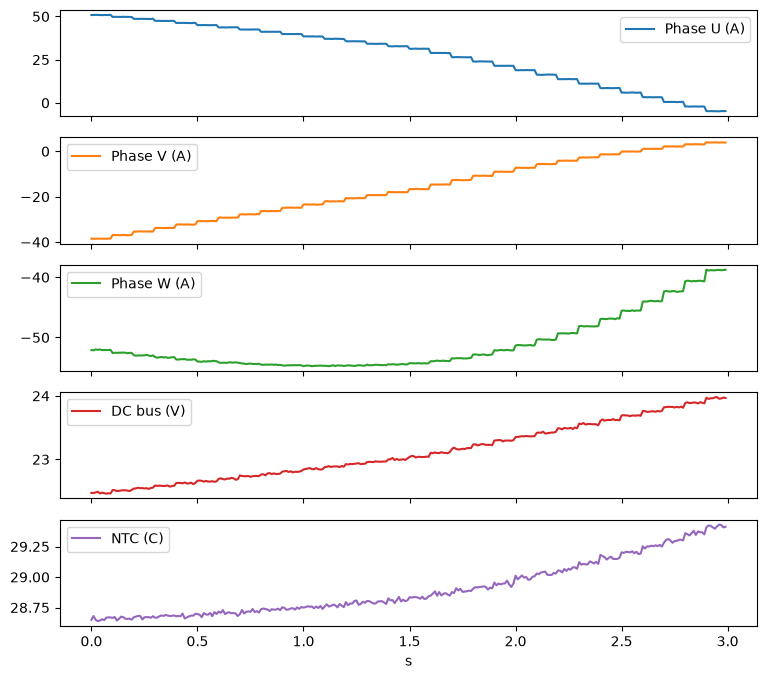

In [7]:
import matplotlib.pyplot as plt

units = [c for c in df.columns if c.endswith('(A)')]
axes = df[units + ['DC bus (V)', 'NTC (C)']].plot(subplots=True, figsize=(9, 8), legend=True)
axes[-1].set_xlabel('s')
plt.show()

The codes stay in the frame under the board's own channel names, so a tare or a span can be checked against what arrived.

In [8]:
print(df[['Phase U', 'Phase U (A)', 'NTC', 'NTC (C)']].iloc[:3])
device.close()

             Phase U  Phase U (A)           NTC    NTC (C)
elapsed                                                   
0.00     8032.153846    50.845277  35010.423077  28.649332
0.01     8032.653846    50.848442  35029.153846  28.680288
0.02     8044.961538    50.926352  35010.730769  28.649840


## Conclusions

In [9]:
codes = [c for c in df.columns if not c.endswith(')')]
scaled = [c for c in df.columns if c.endswith(')')]
print('%d records, %d code columns, %d scaled columns' % (len(df), len(codes), len(scaled)))
for name in ('Phase U', 'DC bus', 'NTC'):
    unit = [c for c in scaled if c.startswith(name)][0]
    span = df[unit].max() - df[unit].min()
    print('%-8s codes %8.1f +/- %6.1f   %-12s %8.3f +/- %.3f  span %.3f'
          % (name, df[name].mean(), df[name].std(), unit, df[unit].mean(),
             df[unit].std(), span))

300 records, 16 code columns, 5 scaled columns
Phase U  codes   4403.9 +/- 2662.6   Phase U (A)    27.878 +/- 16.855  span 55.884
DC bus   codes  19383.3 +/-  373.8   DC bus (V)     23.114 +/- 0.446  span 1.521
NTC      codes  35165.3 +/-  136.2   NTC (C)        28.906 +/- 0.226  span 0.791


A code column is what arrived; the column beside it is what it means. The conversion is the board's own (invariant 7): the scaling lives in the calibration record, so `frame(scaled=True)` asks `board.analog.scaling()` rather than holding a constant, then applies that channel's offset and gain trim. Both columns stay, because what arrived and what it means are two things.

With an empty record every converter falls back to the compiled-in constant and says so in `name`. `calibration.span(index, reference)` writes a gain trim against an instrument, taking the reference in the channel's own unit - mA for a phase, mV for the DC link. The DC link's stands at -32 418 ppm (FINDINGS).

That divider is 49.9k/2.2k: 78.15 V full scale on a 63 V rating, 24 % of headroom so an over-rating transient is recorded rather than clipped (invariant 11).